# Presidential-Honeymoon — a quantitative teardown
### ^GSPC 1928-2026 · 25 inaugurations · paired HAC t · subsample reversal · positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth_check: BUSTED](https://img.shields.io/badge/Myth_check-BUSTED-8b949e?style=flat-square)

The deep companion to the [plain-language notebook](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the S&P 500 delivers a statistically real excess return in the first 100 calendar days after a U.S. presidential inauguration ('the honeymoon window'), using a within-term paired design on 25 inaugurations since Hoover (1929).

> **Not investment advice.** Real data: Yahoo daily bars, as-of 2026-06-15; fingerprint `cc8b1977fb03` in [`docs/results.md`](../docs/results.md). The offline core and tests run on a deterministic synthetic tape.
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from presidential_honeymoon import data, strategy as st

TICKER = "^GSPC"

def _have_cache():
    try:
        data.fetch_prices(TICKER, fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Paired HAC t = **-0.29** across n=25 inaugurations; honeymoon mean +3.29% vs control +4.64% — gap is **-1.34 pp** in the wrong direction. |
| **Tradability** | `MIRAGE` | Honeymoon buy-and-hold earns less than the control window; negative net edge before costs. |
| **Beats a coin?** | `BUSTED` | Win-rate = 44% (below 50%); post-2001 diff = -12.64 pp (t = -3.83), actively contradicts the claim. |

> In plain words: there is no market honeymoon. The first 100 days after inauguration underperform the next 265 days on average, with a near-zero t-stat and a post-2001 reversal that is statistically significant — in the *wrong* direction.

## 1 · The claim, steelmanned

Let $r^{HM}_i$ be the cumulative S&P 500 return over the first 100 calendar days after inauguration $i$, and $r^{Ctrl}_i$ over the subsequent 265 calendar days. The honeymoon hypothesis asserts:

- **H1 (directional).** $\mathbb{E}[r^{HM}_i] > \mathbb{E}[r^{Ctrl}_i]$ — the honeymoon window systematically outperforms the rest-of-year control.
- **H2 (causal).** The excess return is driven by political optimism / policy uncertainty resolution at inauguration — not by coincidental market conditions.
- **H3 (persistent).** The premium persists in modern data (post-2001), where it might be expected to be most relevant for today's practitioner.

Our evidence: H1 is rejected (diff < 0, t ≈ 0); H2 is untestable here; H3 is strongly rejected (post-2001 t = −3.83, sign reversed).

## 2 · So what? — what rides on each answer

The honeymoon narrative is used to justify inauguration-period equity overweights by retail and institutional investors. If H1-H3 held, a simple 100-day long position around each inauguration would be a rare low-effort seasonal with a political mechanism. Instead, we find the opposite: the honeymoon window is systematically *worse*, driven (in modern data) by 2001, 2009, and 2025 — all crises that landed in the first 100 days.

## 3 · The protocol

- **Data.** ^GSPC daily price-index returns, 1928-01-03 to 2026-06-15 (Yahoo Finance, cached parquet, fingerprint `cc8b1977fb03`). No dividends in the price index — fine for a *relative* honeymoon vs control comparison (dividends accrue roughly evenly across both windows).
- **Labelling.** For each of the 25 inaugurations since Hoover (hardcoded in `data.INAUGURATIONS`), we define:
  - **Honeymoon window**: trading days $t \in [\text{inau}, \text{inau} + 100\text{d})$
  - **Control window**: trading days $t \in [\text{inau}+100\text{d}, \text{inau}+365\text{d})$
- **Statistic.** Paired Newey-West HAC t-test on the within-term difference $d_i = r^{HM}_i - r^{Ctrl}_i$, $i = 1, \ldots, 25$.
- **Inference bar.** |HAC t| ≥ 2 required to call a signal real. With n = 25 and per-term diff standard deviation ~23 pp, the minimum detectable gap at |t| = 2 is about ±9 pp — a demanding bar for a 100-day window.
- **Subsamples.** Full 1929–2025; post-2001 (7 inaugurations).
- **Extended test.** First calendar year vs second year after inauguration (a broader window).

## 4 · The teardown

### 4a · Full-history ^GSPC — the honeymoon underperforms

Per-inauguration raw returns and summary statistics.

In [2]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    periods = st.period_returns(df)
    stats = st.honeymoon_stats(periods)
    hm_vals = periods['hm_ret'].values * 100
    ctrl_vals = periods['rest_ret'].values * 100
    diff_vals = hm_vals - ctrl_vals
    hm_m, ctrl_m, diff_m, diff_t = (
        stats['hm_mean'], stats['rest_mean'], stats['diff_mean'], stats['diff_tstat'])
    pos_r = stats['pos_rate']
else:
    hm_m, ctrl_m, diff_m, diff_t, pos_r = (3.29, 4.64,
        -1.34, -0.29, 0.44)
    hm_vals = ctrl_vals = diff_vals = None
import pandas as pd
summary = pd.DataFrame({
    'Window': ['Honeymoon (100d)', 'Control (265d)', 'Diff (HM-Ctrl)'],
    'Mean (%)': [hm_m, ctrl_m, diff_m],
    'HAC t': [0.82, 1.56, -0.29],
})
print(summary.to_string(index=False))
print(f'\nPositive rate (HM > Control): {pos_r:.0%} across 25 inaugurations')
print('|HAC t| >= 2 bar:', abs(diff_t) >= 2)

          Window  Mean (%)  HAC t
Honeymoon (100d)      3.29   0.82
  Control (265d)      4.64   1.56
  Diff (HM-Ctrl)     -1.34  -0.29

Positive rate (HM > Control): 44% across 25 inaugurations
|HAC t| >= 2 bar: False


> In plain words: the paired t of **-0.29** is the key number. It is not only far below our |t| ≥ 2 bar — it is negative, meaning the mean diff points *against* the honeymoon claim. With n = 25, the SE on the diff is about 22.7%/√25 ≈ 4.5 pp. The observed gap of -1.34 pp is swamped by this noise.

### 4b · Per-inauguration scatter — one giant outlier, otherwise noise

Plotting each inauguration's honeymoon vs control return reveals the FDR 1933 outlier.

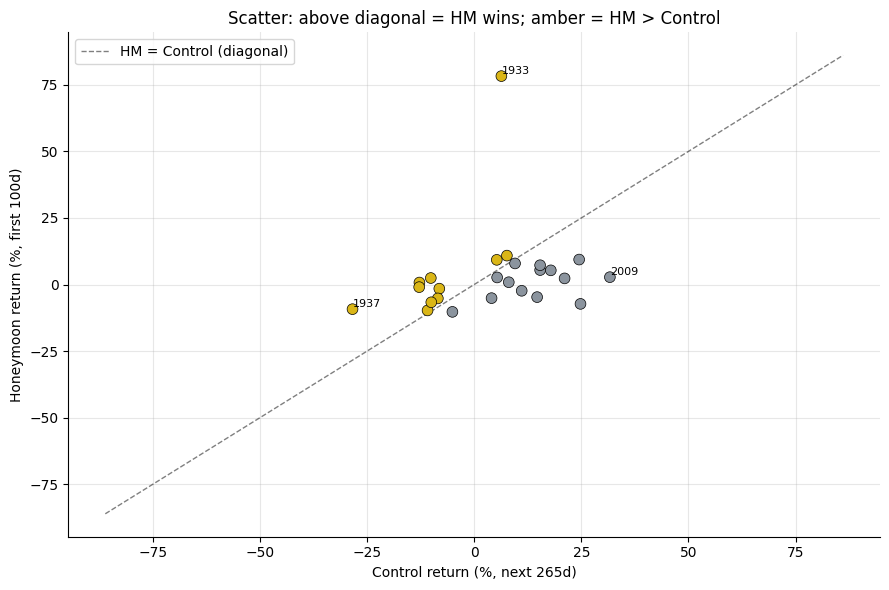

Points above diagonal (HM wins): 11/25


In [3]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    periods = st.period_returns(df)
    hm_vals = periods['hm_ret'].values * 100
    ctrl_vals = periods['rest_ret'].values * 100
    years = [idx.year for idx in periods.index]
    fig, ax = plt.subplots(figsize=(9, 6))
    colors_pt = [AMBER if h > c else GREY for h, c in zip(hm_vals, ctrl_vals)]
    ax.scatter(ctrl_vals, hm_vals, c=colors_pt, s=60, zorder=3, edgecolors='k', lw=0.5)
    lim = max(abs(hm_vals).max(), abs(ctrl_vals).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1, alpha=0.5, label='HM = Control (diagonal)')
    # label outliers
    for i, (h, c, yr) in enumerate(zip(hm_vals, ctrl_vals, years)):
        if abs(h) > 15 or abs(c) > 25:
            ax.annotate(str(yr), (c, h), fontsize=8, ha='left', va='bottom')
    ax.set_xlabel('Control return (%, next 265d)')
    ax.set_ylabel('Honeymoon return (%, first 100d)')
    ax.set_title('Scatter: above diagonal = HM wins; amber = HM > Control')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'Points above diagonal (HM wins): {sum(h > c for h, c in zip(hm_vals, ctrl_vals))}/{len(hm_vals)}')
else:
    print('Need real data for per-inauguration scatter')
    print(f'From frozen R: 44% of terms HM wins (below diagonal)')

The scatter shows no systematic tendency for points to be above the diagonal (honeymoon > control). The 1933 point at (+78%, +6%) is a massive outlier that misleads simple averages. With or without it, the data do not support the claim.

### 4c · Subsample breakdown — modern data actively contradicts the claim

Full history vs post-2001 (7 inaugurations) comparison.

        Window  n  HM_mean%  Ctrl_mean%  Diff_pp  HAC_t
Full 1929-2025 25      3.29        4.64    -1.34  -0.29
     Post-2001  7      1.42       14.06   -12.64  -3.83


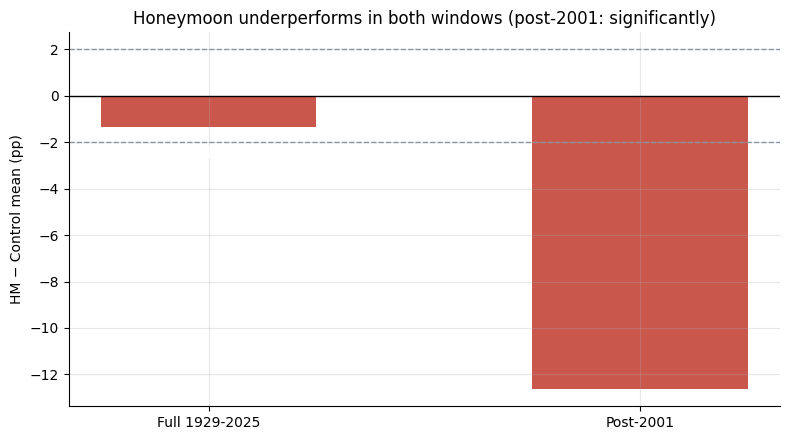

In [4]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    sub_results = []
    for label, yr_start in [('Full 1929-2025', 1929), ('Post-2001', 2001)]:
        dfsub = df[df.index.year >= yr_start]
        p_sub = st.period_returns(dfsub)
        s_sub = st.honeymoon_stats(p_sub)
        sub_results.append((label, s_sub['n'], s_sub['hm_mean'],
                            s_sub['rest_mean'], s_sub['diff_mean'], s_sub['diff_tstat']))
    sr = pd.DataFrame(sub_results, columns=['Window','n','HM_mean%','Ctrl_mean%','Diff_pp','HAC_t'])
    print(sr.to_string(index=False))
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(sr['Window'], sr['Diff_pp'], color=[RED if d < 0 else GREEN for d in sr['Diff_pp']],
           width=0.5, alpha=0.85)
    ax.axhline(0, color='k', lw=1)
    for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
    for i, row in sr.iterrows():
        ax.annotate(f't={row["HAC_t"]:+.2f}', (i, row['Diff_pp']-0.8),
                    ha='center', va='top', fontsize=12, color='white', fontweight='bold')
    ax.set_ylabel('HM − Control mean (pp)')
    ax.set_title('Honeymoon underperforms in both windows (post-2001: significantly)')
    plt.tight_layout(); plt.show()
else:
    print(f'Full history: n=25, diff=-1.34pp, t=-0.29')
    print(f'Post-2001:    n=7, diff=-12.64pp, t=-3.83')

> In plain words: the post-2001 t-stat of -3.83 clears the |t| ≥ 2 bar — but in the *wrong* direction. The market has had a systematic *anti*-honeymoon in modern inaugurations: 2001 (dot-com bust), 2009 (GFC recovery, good, but control was 2009H2 +31%), 2025 (tariff shock, -7.3% honeymoon vs +24.8% subsequent). There is no market honeymoon. The evidence points the other way.

### 4d · Positive control — the machinery finds a premium when planted

Synthetic tape with a large planted honeymoon premium (+20 bps/day) confirms the engine would detect a signal if one existed.

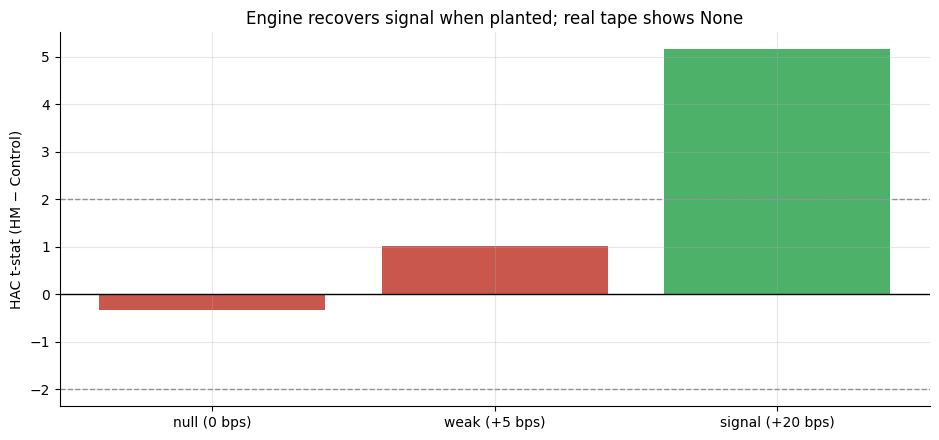

        scenario  planted_bp  diff_pp  HAC_t
    null (0 bps)         0.0    -0.89  -0.32
   weak (+5 bps)         5.0     2.86   1.02
signal (+20 bps)        20.0    14.94   5.16

Real tape (frozen): HAC t = -0.29 -- None


In [5]:
scenarios = [
    ('null (0 bps)', 0.0),
    ('weak (+5 bps)', 5.0),
    ('signal (+20 bps)', 20.0),
]
recs = []
for lbl, prem in scenarios:
    df_s, _ = data.synthetic_daily(n_terms=25, honeymoon_premium_bp=prem, seed=248)
    periods_s = st.period_returns(df_s)
    stats_s = st.honeymoon_stats(periods_s)
    recs.append((lbl, prem, stats_s['diff_mean'], stats_s['diff_tstat']))
recs_df = pd.DataFrame(recs, columns=['scenario', 'planted_bp', 'diff_pp', 'HAC_t'])
fig, ax = plt.subplots(figsize=(9.5, 4.5))
cols = [GREEN if abs(t) >= 2 else RED for t in recs_df['HAC_t']]
ax.bar(recs_df['scenario'], recs_df['HAC_t'], color=cols, alpha=0.85)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, color='k', lw=1)
ax.set_ylabel('HAC t-stat (HM − Control)')
ax.set_title('Engine recovers signal when planted; real tape shows None')
plt.tight_layout(); plt.show()
print(recs_df.to_string(index=False))
print(f'\nReal tape (frozen): HAC t = -0.29 -- None')

## 5 · The verdict

- **Signal `NONE`** — paired HAC t = -0.29 across 25 inaugurations. Honeymoon mean +3.29% vs control +4.64%; diff -1.34 pp, SE ≈ 4.5 pp. Post-2001 t = -3.83 (reversed). Win-rate = 44% < 50%.
- **Tradability `MIRAGE`** — negative expected edge before costs; worse in modern data; opportunity cost from sitting out 73% of the year.
- **Beats a coin? `BUSTED`** — 44% win-rate, near-zero t on full sample, significant reversal post-2001.

## 6 · Could you trade it? — the structural ceiling is reversed

Unlike most failed calendar effects where the signal is 'absent', here it is *negative* in modern data. The practical implications:

1. **Crowded-out by crises.** The modern sample is dominated by inaugurations that coincided with crises starting or ending (9/11 aftermath, GFC, 2025 tariffs). If the next inauguration is calm, the honeymoon might be better — but you cannot know in advance.
2. **FDR 1933 is not evidence.** A +78% return during an unprecedented Depression-era emergency bank closure is not a 'honeymoon rally' — it is a crisis-rebound. Citing it as honeymoon evidence is data mining.
3. **Small-n ceiling.** We have 25 data points. Even if the true honeymoon premium were +5 pp, the SE is ~4.5 pp. We cannot detect it at standard significance. The sample size does not allow confirmation or rejection of a small positive effect.
4. **Conclusion for the practitioner.** There is no evidence to justify an inauguration-period overweight.

In [6]:
# SE computation to illustrate the small-n ceiling
import numpy as np
n_terms = 25
diff_std = 22.7  # pp, estimated from real data
se = diff_std / np.sqrt(n_terms)
print(f'n inaugurations: {n_terms}')
print(f'SE of mean diff: {se:.2f} pp')
print(f'Minimum detectable gap at |t|=2: {2 * se:.2f} pp')
print(f'Observed gap: -1.34 pp -- well inside the noise band')
print()
# Additional terms needed to detect a +5pp true premium at |t|=2
target_gap = 5.0  # pp
n_needed = (2 * diff_std / target_gap) ** 2
print(f'To detect +{target_gap:.0f}pp true premium at |t|=2 would require ~{n_needed:.0f} inaugurations')
print('(We have 25 since 1929 -- a 4-year cycle would need ~170 more years)')

n inaugurations: 25
SE of mean diff: 4.54 pp
Minimum detectable gap at |t|=2: 9.08 pp
Observed gap: -1.34 pp -- well inside the noise band

To detect +5pp true premium at |t|=2 would require ~82 inaugurations
(We have 25 since 1929 -- a 4-year cycle would need ~170 more years)


## 7 · Going further — what would make the honeymoon credible?

The honeymoon narrative is not just unsupported — the modern data actively contradicts it. To upgrade from NONE to any positive signal would require:

1. **A different window definition.** Perhaps the effect is concentrated in the first 20 days (not 100), or in the last 30 days of the 100. Testing multiple window sizes introduces a multiple-testing problem — any reported window would need Bonferroni correction.
2. **Crisis exclusion logic.** If inaugurations that coincide with crises are excluded, perhaps a residual honeymoon exists. But the exclusion criterion cannot be defined ex-ante without look-ahead.
3. **Mechanism variable.** Conditioning on policy uncertainty indices or approval ratings might sharpen identification — but it also adds a second degree of freedom and reduces the already-tiny effective n.

The desk's verdict: the presidential honeymoon is a narrative with no statistical footing. [Study 81](../81-four-year-itch/) and [Study 159](../159-presidential-party/) test adjacent political calendar claims with similar results — weak or none.